In [1]:
import os
import sys
from pathlib import Path

ROOT = Path(os.getcwd()).resolve().parents[1]  # bart-playground root
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

notebook = "real1_Abalone_pt_mtmh"

In [2]:
import numpy as np
from ucimlrepo import fetch_ucirepo

# Load Abalone and drop categorical Sex
abalone = fetch_ucirepo(id=1)
X = abalone.data.features.drop(columns=["Sex"]).values.astype(float)
y = np.asarray(abalone.data.targets).reshape(-1)

X.shape, y.shape

((4177, 7), (4177,))

In [ ]:
from experiment import run_parallel_experiments

ndpost = 2000
nskip = 0
n_trees = 100

# You can scale these up for final experiments
n_runs = 5
n_chains = 4
n_jobs = 5

default_proposal_probs = {"grow": 0.4, "prune": 0.4, "change": 0.1, "swap": 0.1}
mtmh_proposal_probs = {"multi_grow": 0.4, "multi_prune": 0.4, "multi_change": 0.1, "multi_swap": 0.1}

results = run_parallel_experiments(
    X=X,
    y=y,
    ndpost=ndpost,
    nskip=nskip,
    n_trees=n_trees,
    notebook=notebook,
    n_runs=n_runs,
    n_chains=n_chains,
    n_jobs=n_jobs,
    store_preds=True,
    n_test_points=100,
    swap_interval=50,
    ladder_target_rate=0.4,
    ladder_max_rounds=10,
    ladder_ndpost=500,
    ladder_nskip=100,
    ladder_repeats=3,
    ladder_search_points=500,
    ladder_initial_temperatures=(1.0, 1000000.0),
    proposal_probs_default=default_proposal_probs,
    proposal_probs_mtmh=mtmh_proposal_probs,
    multi_tries=10,
    store_dir="store",
    progress_print=True,
 )

print(f"Finished. Stored CSV files under: {Path('store').resolve()}")

In [3]:
from IPython.display import display
import ast
import pandas as pd
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from scipy.stats import gaussian_kde
from tabpfn import TabPFNRegressor
import matplotlib.pyplot as plt
import numpy as np

comparison_specs = [
    ("default", "default", "tab:blue"),
    ("default_pt", "default_pt", "tab:orange"),
    ("mtmh", "mtmh", "tab:green"),
    ("mtmh_pt", "mtmh+pt", "tab:red"),
]

comparison_labels = {key: label for key, label, _ in comparison_specs}
comparison_colors = {key: color for key, _, color in comparison_specs}
comparison_colors_by_label = {label: color for key, label, color in comparison_specs}
comparison_colors_by_label["tabpfn"] = "tab:purple"
comparison_colors_by_label["y_test_sub"] = "black"

def ensure_point_by_sample(arr, n_points):
    arr = np.asarray(arr, dtype=float)
    if arr.ndim != 2:
        raise ValueError(f"Expected 2D array, got shape={arr.shape}")
    if arr.shape[0] == n_points:
        return arr
    if arr.shape[1] == n_points:
        return arr.T
    raise ValueError(f"Could not align samples with n_points={n_points}, shape={arr.shape}")

def crps_from_samples(samples, y_true):
    n_points, n_samples = samples.shape
    term1 = np.mean(np.abs(samples - y_true[:, None]), axis=1)
    samples_sorted = np.sort(samples, axis=1)
    k = np.arange(1, n_samples + 1)
    coeffs = (2 * k - n_samples - 1)[None, :]
    term2 = np.sum(coeffs * samples_sorted, axis=1) / (n_samples ** 2)
    return term1 - term2

def _load_numeric_csv(file_path):
    with open(file_path, "r", encoding="utf-8") as f:
        header = f.readline().strip()
    original_shape = None
    if header.startswith("# original_shape="):
        original_shape = ast.literal_eval(header[len("# original_shape="):])
    data = np.loadtxt(file_path, delimiter=",", comments="#", skiprows=1)
    data = np.asarray(data)
    if original_shape is not None:
        return data.reshape(original_shape)
    return data

def load_results_from_store(store_root, notebook):
    metadata_files = sorted((store_root / "metadata").glob(f"{notebook}__run*.csv"))
    if not metadata_files:
        raise FileNotFoundError(f"No stored runs found for notebook={notebook} in {store_root}")

    results = []
    for metadata_file in metadata_files:
        run_id = int(metadata_file.stem.split("__run")[-1])
        run_tag = f"{notebook}__run{run_id:03d}"
        meta = pd.read_csv(metadata_file).set_index("key")["value"].to_dict()
        run_result = {
            "run_id": run_id,
            "split_seed": int(meta["split_seed"]),
            "subsample": {
                "X_test": _load_numeric_csv(store_root / "subsample_X_test" / f"{run_tag}__subsample_X_test.csv"),
                "y_test": _load_numeric_csv(store_root / "subsample_y_test" / f"{run_tag}__subsample_y_test.csv").reshape(-1),
            },
        }
        for model_name in ["default", "default_pt", "mtmh", "mtmh_pt"]:
            run_result[model_name] = {
                "preds": _load_numeric_csv(store_root / "preds" / f"{run_tag}__{model_name}__preds.csv"),
                "sigmas": _load_numeric_csv(store_root / "sigmas" / f"{run_tag}__{model_name}__sigmas.csv"),
            }
        results.append(run_result)
    return results

store_root = Path("store")
results = load_results_from_store(store_root, notebook)

rows_rmse = []
rows_crps = []
for run in results:
    run_id = int(run["run_id"])
    split_seed = int(run["split_seed"])
    y_test_sub = np.asarray(run["subsample"]["y_test"], dtype=float).reshape(-1)
    X_test_sub = np.asarray(run["subsample"]["X_test"], dtype=float)
    row_rmse = {"run_id": run_id}
    row_crps = {"run_id": run_id}
    for key, label, _ in comparison_specs:
        pred_stack = np.asarray(run[key]["preds"], dtype=float)
        chain_rmse = []
        chain_crps = []
        for chain_pred in pred_stack:
            samples = ensure_point_by_sample(chain_pred, n_points=y_test_sub.shape[0])
            pred_mean = np.mean(samples, axis=1)
            chain_rmse.append(root_mean_squared_error(y_test_sub, pred_mean))
            chain_crps.append(float(np.mean(crps_from_samples(samples, y_test_sub))))
        row_rmse[label] = float(np.mean(chain_rmse))
        row_crps[label] = float(np.mean(chain_crps))

    X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=split_seed)
    tabpfn_model = TabPFNRegressor(random_state=42, ignore_pretraining_limits=True)
    tabpfn_model.fit(X_train, y_train)
    tabpfn_pred = np.asarray(tabpfn_model.predict(X_test_sub), dtype=float).reshape(-1)
    row_rmse["tabpfn"] = float(root_mean_squared_error(y_test_sub, tabpfn_pred))

    rows_rmse.append(row_rmse)
    rows_crps.append(row_crps)

rmse_table = pd.DataFrame(rows_rmse).sort_values("run_id").set_index("run_id")
crps_table = pd.DataFrame(rows_crps).sort_values("run_id").set_index("run_id")

print("RMSE table (rows=runs, cols=models):")
display(rmse_table)
print("\nCRPS table (rows=runs, cols=models):")
display(crps_table)

SELECT_RUN_INDEX = 0
SELECT_CHAIN_ID = 0
selected_run = results[SELECT_RUN_INDEX]
selected_y_test = np.asarray(selected_run["subsample"]["y_test"], dtype=float).reshape(-1)
selected_X_test = np.asarray(selected_run["subsample"]["X_test"], dtype=float)

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=int(selected_run["split_seed"]))
tabpfn_model = TabPFNRegressor(random_state=42, ignore_pretraining_limits=True)
tabpfn_model.fit(X_train, y_train)
tabpfn_pred = np.asarray(tabpfn_model.predict(selected_X_test), dtype=float).reshape(-1)
tabpfn_rmse = root_mean_squared_error(selected_y_test, tabpfn_pred)

comparison_arrays = {}
comparison_pc1 = {}
comparison_sigma_traces = {}
comparison_joint_coords = None
comparison_centroids = {}

joint_prediction_blocks = []
joint_prediction_labels = []

for key, label, _ in comparison_specs:
    chain_preds = np.asarray(selected_run[key]["preds"], dtype=float)[SELECT_CHAIN_ID]
    samples = ensure_point_by_sample(chain_preds, n_points=selected_y_test.shape[0])
    comparison_arrays[key] = samples
    comparison_pc1[key] = PCA(n_components=1).fit_transform(samples.T).ravel()
    comparison_sigma_traces[key] = np.asarray(selected_run[key]["sigmas"], dtype=float)[SELECT_CHAIN_ID].reshape(-1)
    joint_prediction_blocks.append(samples.T)
    joint_prediction_labels.append(np.repeat(label, samples.shape[1]))

joint_predictions = np.vstack(joint_prediction_blocks)
joint_labels = np.concatenate(joint_prediction_labels)
comparison_pca2 = PCA(n_components=2, random_state=42)
comparison_joint_coords = comparison_pca2.fit_transform(joint_predictions)
tabpfn_coords = comparison_pca2.transform(tabpfn_pred.reshape(1, -1))[0]
y_test_coords = comparison_pca2.transform(selected_y_test.reshape(1, -1))[0]
for key, label, _ in comparison_specs:
    mask = joint_labels == label
    comparison_centroids[key] = comparison_joint_coords[mask].mean(axis=0)

print(f"Selected run index: {SELECT_RUN_INDEX}, run_id: {int(selected_run['run_id'])}, chain: {SELECT_CHAIN_ID}")
for key, label, _ in comparison_specs:
    print(f"{label} centroid:", comparison_centroids[key])

RMSE table (rows=runs, cols=models):


,default,default_pt,mtmh,mtmh+pt,tabpfn
run_id,,,,,
0,1.901989,1.942729,1.928650,1.921353,1.641190
1,2.086762,2.085783,2.069922,2.047638,1.911551
2,1.857100,1.813359,1.859214,1.816078,1.812586
3,2.088529,2.013923,2.127282,2.029832,2.013238
4,2.248785,2.202021,2.249924,2.193451,2.195739



CRPS table (rows=runs, cols=models):


,default,default_pt,mtmh,mtmh+pt
run_id,,,,
0,1.071560,1.105283,1.082990,1.088434
1,1.140503,1.138415,1.131698,1.119855
2,0.952854,0.946517,0.943098,0.941004
3,1.123282,1.098594,1.135667,1.101035
4,1.196479,1.184349,1.197212,1.178042


Selected run index: 0, run_id: 0, chain: 0
default centroid: [ 2.19378445 -0.92286521]
default_pt centroid: [-2.70340955 -0.03011457]
mtmh centroid: [1.94171591 1.37431814]
mtmh+pt centroid: [-1.43209081 -0.42133836]


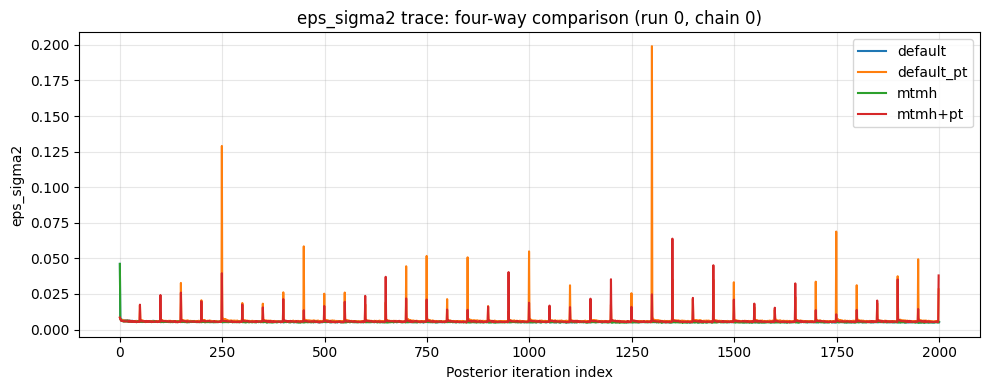

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))
for key, _, _ in comparison_specs:
    ax.plot(comparison_sigma_traces[key], label=comparison_labels[key], color=comparison_colors[key])

ax.set_xlabel("Posterior iteration index")
ax.set_ylabel("eps_sigma2")
ax.set_title(f"eps_sigma2 trace: four-way comparison (run {int(selected_run['run_id'])}, chain {SELECT_CHAIN_ID})")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

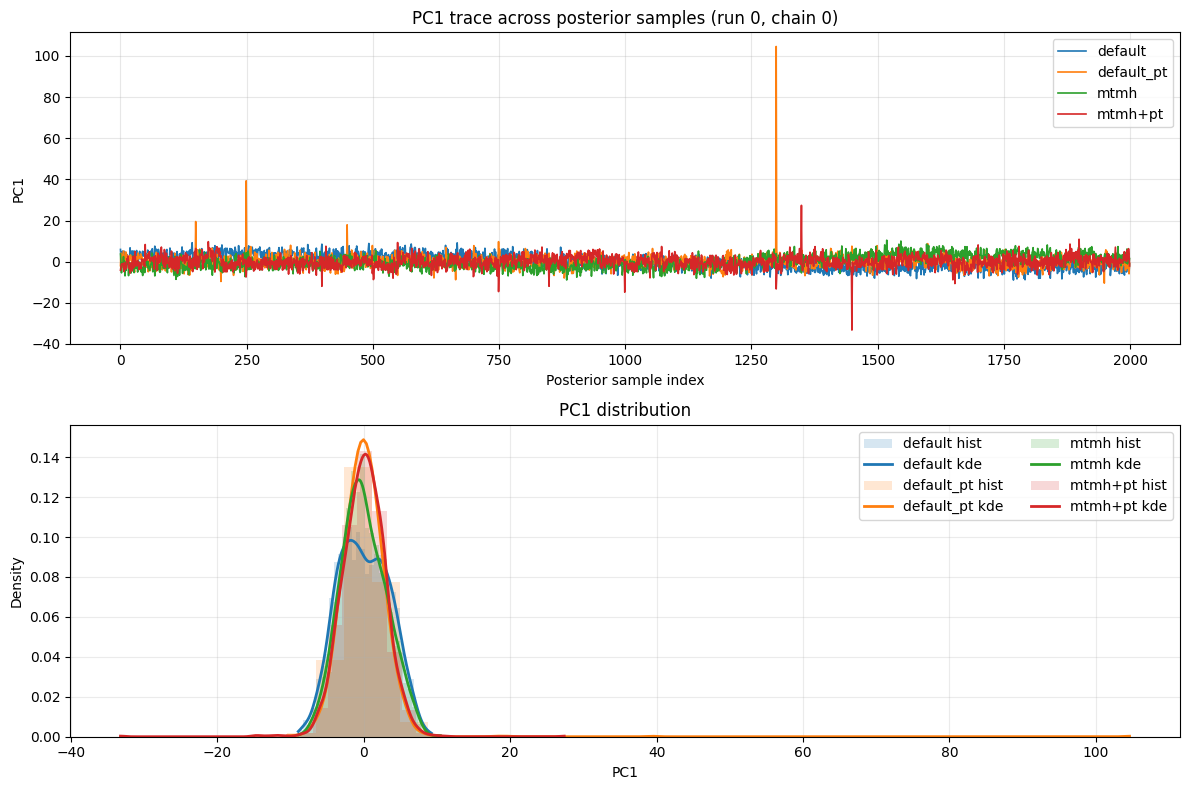

In [5]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)

for key, _, _ in comparison_specs:
    axes[0].plot(comparison_pc1[key], lw=1.2, label=comparison_labels[key], color=comparison_colors[key])

axes[0].set_title(f"PC1 trace across posterior samples (run {int(selected_run['run_id'])}, chain {SELECT_CHAIN_ID})")
axes[0].set_xlabel("Posterior sample index")
axes[0].set_ylabel("PC1")
axes[0].grid(alpha=0.3)
axes[0].legend()

for key, _, _ in comparison_specs:
    pc1 = comparison_pc1[key]
    axes[1].hist(pc1, bins=30, density=True, alpha=0.18, color=comparison_colors[key], label=f"{comparison_labels[key]} hist")
    x_grid = np.linspace(np.min(pc1), np.max(pc1), 300)
    kde = gaussian_kde(pc1)
    axes[1].plot(x_grid, kde(x_grid), color=comparison_colors[key], linewidth=2.0, label=f"{comparison_labels[key]} kde")

axes[1].set_title("PC1 distribution")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("Density")
axes[1].grid(alpha=0.25)
axes[1].legend(ncol=2)

plt.tight_layout()
plt.show()

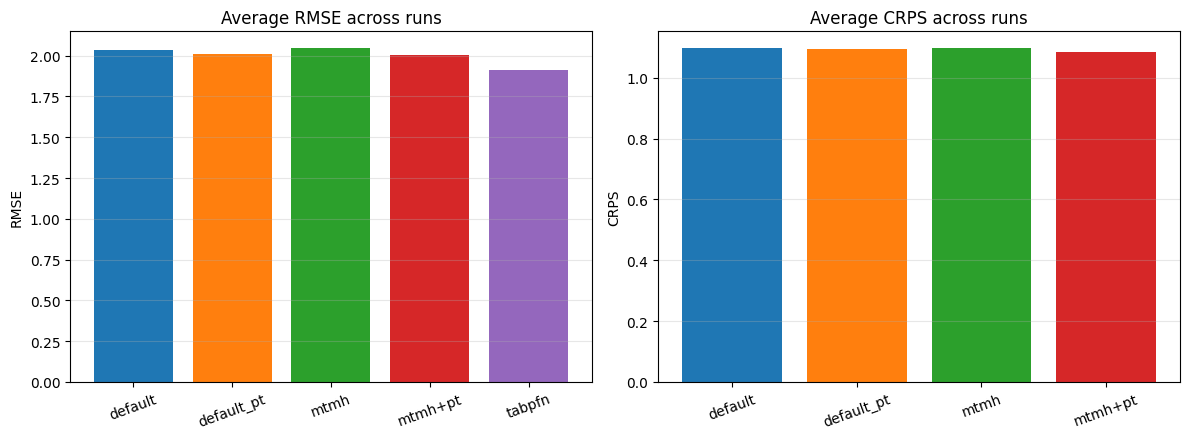

In [6]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

rmse_means = rmse_table.mean(axis=0)
crps_means = crps_table.mean(axis=0)

axes[0].bar(rmse_means.index, rmse_means.values, color=[comparison_colors_by_label.get(label, "gray") for label in rmse_means.index])
axes[0].set_title("Average RMSE across runs")
axes[0].set_ylabel("RMSE")
axes[0].tick_params(axis="x", rotation=20)
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(crps_means.index, crps_means.values, color=[comparison_colors_by_label.get(label, "gray") for label in crps_means.index])
axes[1].set_title("Average CRPS across runs")
axes[1].set_ylabel("CRPS")
axes[1].tick_params(axis="x", rotation=20)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

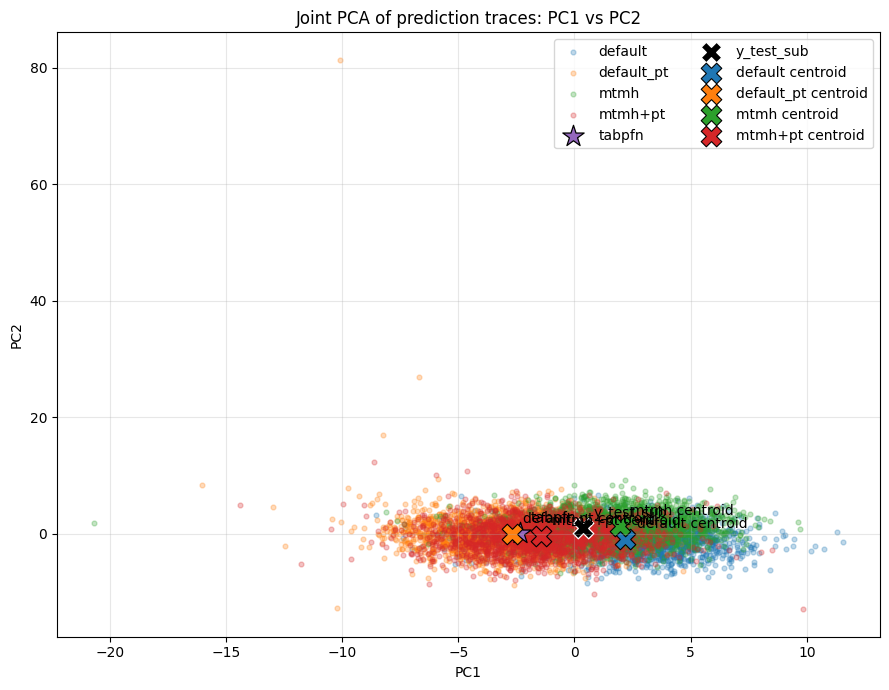

Explained variance ratio: [0.02143325 0.01521255]
tabpfn coords: [-2.35198043  0.17424399]
y_test_sub coords: [0.35978697 0.96903695]
default centroid: [ 2.19378445 -0.92286521]
default_pt centroid: [-2.70340955 -0.03011457]
mtmh centroid: [1.94171591 1.37431814]
mtmh+pt centroid: [-1.43209081 -0.42133836]


In [7]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(9, 7))

for key, label, _ in comparison_specs:
    coords = comparison_joint_coords[joint_labels == label]
    ax.scatter(coords[:, 0], coords[:, 1], s=12, alpha=0.28, label=label, color=comparison_colors[key])

ax.scatter(
    tabpfn_coords[0], tabpfn_coords[1],
    s=260, marker="*", color=comparison_colors_by_label["tabpfn"],
    edgecolor="black", linewidth=0.9, label="tabpfn",
)
ax.scatter(
    y_test_coords[0], y_test_coords[1],
    s=220, marker="X", color=comparison_colors_by_label["y_test_sub"],
    edgecolor="white", linewidth=0.9, label="y_test_sub",
)

for key, label, _ in comparison_specs:
    centroid = comparison_centroids[key]
    ax.scatter(
        centroid[0], centroid[1],
        s=220, marker="X", color=comparison_colors[key], edgecolor="black", linewidth=0.8,
        label=f"{label} centroid",
    )
    ax.annotate(
        f"{label} centroid",
        (centroid[0], centroid[1]),
        xytext=(8, 8),
        textcoords="offset points",
    )

ax.annotate("tabpfn", (tabpfn_coords[0], tabpfn_coords[1]), xytext=(8, 8), textcoords="offset points")
ax.annotate("y_test_sub", (y_test_coords[0], y_test_coords[1]), xytext=(8, 8), textcoords="offset points")

ax.set_title("Joint PCA of prediction traces: PC1 vs PC2")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.grid(alpha=0.3)
ax.legend(loc="best", ncol=2)
plt.tight_layout()
plt.show()

print("Explained variance ratio:", comparison_pca2.explained_variance_ratio_)
print("tabpfn coords:", tabpfn_coords)
print("y_test_sub coords:", y_test_coords)
for key, label, _ in comparison_specs:
    print(f"{label} centroid:", comparison_centroids[key])